## Emotion detection using Librosa

#### Librosa: Python library used for audio and music signal analysis

In [117]:
import librosa

##toy example
y, sr = librosa.load("audio.wav")
mfcc = librosa.feature.mfcc(y=y, sr=sr)
mfcc.shape

(20, 256)

#### Extract features from audio file

In [118]:
import numpy as np

def extract_feats_audio(filename):
    """Extracts MFCC, chroma, and mel features from an audio file and returns a combined feature vector."""
    y, sr = librosa.load(filename, sr=None)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)

    features = np.hstack([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.mean(chroma, axis=1),
        np.mean(mel, axis=1)
    ])

    return features

In [119]:
feats = extract_feats_audio("Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav")
print("Features shape: ", feats.shape)

Features shape:  (220,)


#### Extract emotion tags and load features per audio file (RAVDESS dataset)

In [120]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

def get_label(filename):
    emotion_code = filename.split("-")[2]
    return emotion_map[emotion_code]

file = "03-01-05-02-02-01-12.wav"
print(get_label(file))

angry


In [121]:
import os

data = []
labels = []
feats = []

for root, dirs, files in os.walk("Audio_Speech_Actors_01-24"):
    for file in files:
        if file.endswith(".wav"):
            label = get_label(file)
            data.append(os.path.join(root, file))
            labels.append(list(emotion_map.values()).index(label))
            feats.append(extract_feats_audio(os.path.join(root, file)))

#### Train/test split

In [122]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = np.vstack(feats)
y_labels = np.array(labels)

#standardise for better results
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (1152, 220) X_test: (288, 220)
y_train: (1152,) y_test: (288,)


#### Train SVM classifier to detect emotion

In [123]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm_model.fit(X_train, y_train)

print("SVM training complete.")

SVM training complete.


Test accuracy: 0.7534722222222222

Classification report:
              precision    recall  f1-score   support

     neutral       0.70      0.74      0.72        19
        calm       0.95      0.92      0.93        38
       happy       0.61      0.71      0.66        38
         sad       0.67      0.63      0.65        38
       angry       0.71      0.69      0.70        39
     fearful       0.87      0.67      0.75        39
     disgust       0.71      0.84      0.77        38
   surprised       0.84      0.82      0.83        39

    accuracy                           0.75       288
   macro avg       0.76      0.75      0.75       288
weighted avg       0.76      0.75      0.75       288

Confusion matrix:


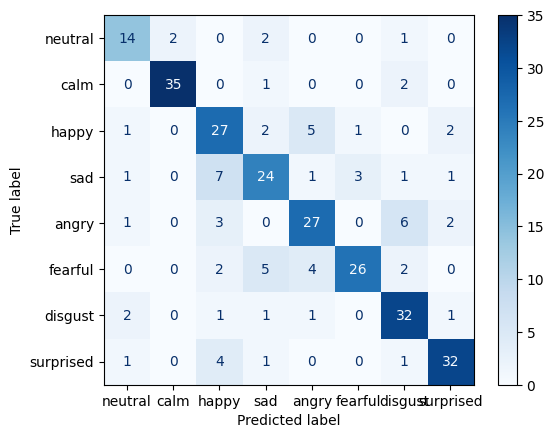

In [124]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = svm_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
class_names = [emotion_map[k] for k in sorted(emotion_map.keys())]
_base_classification_report = classification_report
classification_report = lambda y_true, y_pred, **kwargs: _base_classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    **kwargs
)
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion matrix:")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=class_names).plot(cmap="Blues")

#### Let's try a different classifier (MLP)

In [125]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500)
mlp_model.fit(X_train, y_train)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,None


Test accuracy: 0.7430555555555556

Classification report:
              precision    recall  f1-score   support

     neutral       0.67      0.63      0.65        19
        calm       0.90      0.92      0.91        38
       happy       0.64      0.66      0.65        38
         sad       0.67      0.63      0.65        38
       angry       0.77      0.69      0.73        39
     fearful       0.80      0.72      0.76        39
     disgust       0.74      0.82      0.78        38
   surprised       0.73      0.82      0.77        39

    accuracy                           0.74       288
   macro avg       0.74      0.74      0.74       288
weighted avg       0.74      0.74      0.74       288

Confusion matrix:


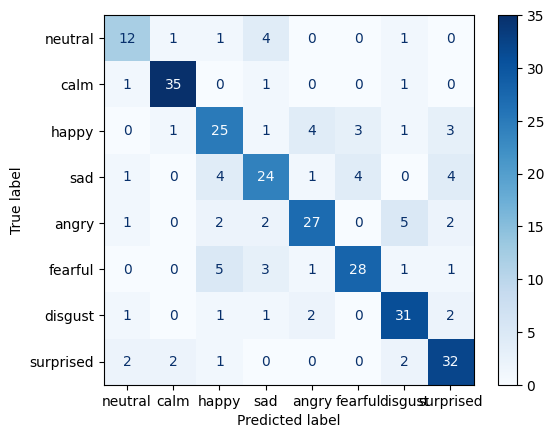

In [126]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = mlp_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
class_names = [emotion_map[k] for k in sorted(emotion_map.keys())]
_base_classification_report = classification_report
classification_report = lambda y_true, y_pred, **kwargs: _base_classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    **kwargs
)
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion matrix:")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=class_names).plot(cmap="Blues")

# Praat

In [ ]:
pip install praat-parselmouth

In [139]:
import parselmouth
import numpy as np
import pandas as pd

file_angry = "Audio_Speech_Actors_01-24/Actor_01/03-01-05-01-01-01-01.wav"
file_sad = "Audio_Speech_Actors_01-24/Actor_01/03-01-04-01-01-01-01.wav"

def get_intensity_features(path):
    snd = parselmouth.Sound(path)
    intensity = snd.to_intensity()

    values = intensity.values[0]

    mean_intensity = np.mean(values)
    std_intensity = np.std(values)
    max_intensity = np.max(values)

    return mean_intensity, std_intensity, max_intensity

angry_stats = get_intensity_features(file_angry)
sad_stats = get_intensity_features(file_sad)

intensity_df = pd.DataFrame(
    {
        "emotion": ["angry", "sad"],
        "max": [angry_stats[2], sad_stats[2]],
        "std": [angry_stats[1], sad_stats[1]],
        "mean": [angry_stats[0], sad_stats[0]],
    }
)
print("Intensity:")
intensity_df

Intensity:


,emotion,max,std,mean
0,angry,69.695578,67.837276,14.126528
1,sad,58.900184,52.892271,8.223165


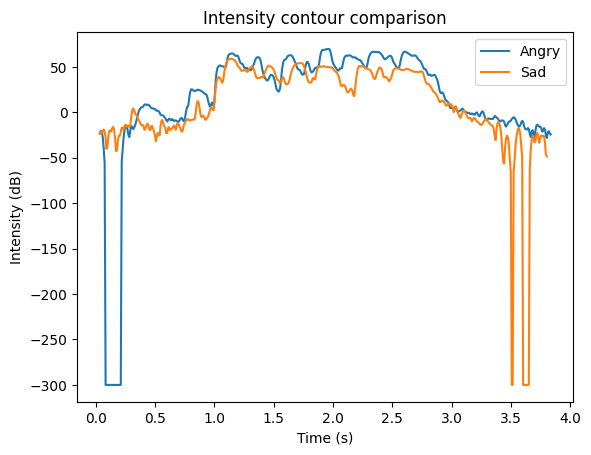

In [135]:
import matplotlib.pyplot as plt

def plot_intensity(path, label):
    snd = parselmouth.Sound(path)
    intensity = snd.to_intensity()

    times = intensity.xs()
    values = intensity.values[0]

    plt.plot(times, values, label=label)

plt.figure()

plot_intensity(file_angry, "Angry")
plot_intensity(file_sad, "Sad")

plt.xlabel("Time (s)")
plt.ylabel("Intensity (dB)")
plt.title("Intensity contour comparison")
plt.legend()

plt.show()